<a href="https://colab.research.google.com/github/ZolisaSilolo/zindi_nedbank_forecast/blob/main/notebooks/00_colab_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nedbank Forecast — Full Colab Pipeline
Run cells top to bottom. Runtime: T4 GPU.

In [1]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import zipfile, os, gdown

DRIVE_DIR = '/content/drive/MyDrive/nedbank_raw'
os.makedirs(DRIVE_DIR, exist_ok=True)

# Remove old corrupted file if it exists
corrupted = f'{DRIVE_DIR}/transactions_features.parquet'
if os.path.exists(corrupted) and os.path.getsize(corrupted) == 0:
    os.remove(corrupted)
    print('Removed corrupted transactions_features.parquet')

# Handle Transactions via gdown (if not already extracted)
parquet_path = f'{DRIVE_DIR}/transactions_features.parquet'
if not os.path.exists(parquet_path):
    zip_path = '/tmp/transactions_features.zip'
    file_id = '19hy_SqwzM2JeYXsPdb0Y4xTn_QZH-qRq'
    url = f'https://drive.google.com/uc?id={file_id}'

    print('Attempting to download transactions_features.zip via gdown...')
    try:
        gdown.download(url, zip_path, quiet=False, fuzzy=True)
        if os.path.exists(zip_path):
            print('Extracting transactions_features.zip...')
            with zipfile.ZipFile(zip_path, 'r') as z:
                z.extractall(DRIVE_DIR)
            os.remove(zip_path)
    except Exception as e:
        print(f'Download failed: {e}')
        print('Please manually upload transactions_features.zip to your Drive root.')
else:
    print('transactions_features.parquet already exists.')

# Handle Financials via Drive
fin_parquet = f'{DRIVE_DIR}/financials_features.parquet'
if not os.path.exists(fin_parquet):
    fin_zip = '/content/drive/MyDrive/financials_features.zip'
    if os.path.exists(fin_zip):
        print('Extracting financials_features.zip...')
        with zipfile.ZipFile(fin_zip, 'r') as z:
            z.extractall(DRIVE_DIR)
    else:
        print('Warning: financials_features.zip not found in Drive root.')
else:
    print('financials_features.parquet already exists.')

print('\nFiles in nedbank_raw:', os.listdir(DRIVE_DIR))

transactions_features.parquet already exists.
financials_features.parquet already exists.

Files in nedbank_raw: ['financials_features.parquet', '__MACOSX', 'transactions_features.parquet']


In [3]:
import polars as pl
print(pl.scan_parquet('/content/drive/MyDrive/nedbank_raw/financials_features.parquet').collect_schema())

Schema({'UniqueID': String, 'AccountID': String, 'RunDate': Datetime(time_unit='ns', time_zone=None), 'Product': String, 'NetInterestIncome': Float64, 'NetInterestRevenue': Float64})


In [4]:
import polars as pl
trans_path = '/content/drive/MyDrive/nedbank_raw/transactions_features.parquet'
if os.path.exists(trans_path):
    print(pl.scan_parquet(trans_path).collect_schema())
else:
    print('transactions_features.parquet not found.')

Schema({'UniqueID': String, 'AccountID': String, 'TransactionDate': Datetime(time_unit='ns', time_zone=None), 'TransactionAmount': Float64, 'TransactionTypeDescription': String, 'TransactionBatchDescription': String, 'StatementBalance': Float64, 'IsDebitCredit': String, 'ReversalTypeDescription': String})


In [5]:
# 3. Set env vars — reads HF_TOKEN from Colab Secrets
import os
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
# Updated to use underscore to avoid URL-encoding/slash issues
os.environ['HF_REPO']  = 'nedbank_features'
os.environ['DATA_DIR'] = DRIVE_DIR

In [6]:
from huggingface_hub import HfApi, create_repo
import os

# Initialize API with your token
api = HfApi(token=os.environ['HF_TOKEN'])

repo_id = os.environ['HF_REPO']

try:
    # Create the repository as a dataset
    repo_url = create_repo(
        repo_id=repo_id,
        repo_type='dataset',
        exist_ok=True,
        private=True
    )
    print(f"Repository successfully verified/created: {repo_url}")
except Exception as e:
    print(f"Error creating repository: {e}")
    print("Note: Ensure your HF_TOKEN has 'write' permissions.")

Repository successfully verified/created: https://huggingface.co/datasets/Zolisa/nedbank_features


In [7]:
# 4. Install dependencies
!pip install -q polars==1.28.1 huggingface_hub pyarrow python-dotenv lightgbm catboost xgboost==3.2.0 joblib gdown scipy
!git clone --depth 1 https://github.com/google-research/timesfm.git /tmp/timesfm
!pip install -q -e '/tmp/timesfm[torch]'

fatal: destination path '/tmp/timesfm' already exists and is not an empty directory.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for timesfm (pyproject.toml) ... done


In [8]:
# 5. Clone repo and refresh .env with updated variables
!rm -rf zindi_nedbank_forecast
!git clone https://github.com/ZolisaSilolo/zindi_nedbank_forecast.git
%cd zindi_nedbank_forecast

# Writing environment variables to .env for the python scripts to pick up
with open('.env', 'w') as f:
    f.write(f"HF_TOKEN={os.environ['HF_TOKEN']}\n")
    f.write(f"HF_REPO={os.environ['HF_REPO']}\n")
    f.write(f"DATA_DIR={os.environ['DATA_DIR']}\n")

print("Environment file .env updated with HF_REPO:", os.environ['HF_REPO'])

Cloning into 'zindi_nedbank_forecast'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 72 (delta 22), reused 66 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 277.53 KiB | 6.94 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/zindi_nedbank_forecast
Environment file .env updated with HF_REPO: nedbank_features


In [9]:
# 6. NODE 1 — Feature engineering (reads from Drive, uploads to HF)
!git pull
!python src/data/01_sagemaker_refinery.py

Already up to date.
Initiating 18M row aggregation from /content/drive/MyDrive/nedbank_raw...
Wrote 11944 rows → data/processed/customer_base_features.parquet
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '404 Not Found' for url 'https://huggingface.co/api/datasets/nedbank_features/preupload/main'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/content/zindi_nedbank_forecast/src/data/01_sagemaker_refinery.py", line 86, in <module>
    process_and_upload()
  File "/content/zindi_nedbank_forecast/src/data/

In [16]:
# 7. NODE 2 — Robust Patch & Run TimesFM Inference
import os
import re

script_path = 'src/features/02_timesfm_features.py'
with open(script_path, 'r') as f:
    content = f.read()

# Use re.DOTALL to match across newlines in case the function call is split
pattern = r"pl\.read_parquet\(.*?hf://.*?\)"

replacement = """(pl.read_parquet('data/processed/customer_base_features.parquet')
                   if os.path.exists('data/processed/customer_base_features.parquet')
                   else pl.read_parquet(f"hf://datasets/Zolisa/{os.environ.get('HF_REPO')}/customer_base_features.parquet"))"""

if re.search(pattern, content, flags=re.DOTALL):
    new_content = re.sub(pattern, replacement, content, flags=re.DOTALL)
    with open(script_path, 'w') as f:
        f.write(new_content)
    print("Script successfully patched with multi-line regex.")
else:
    print("Regex patch failed. Printing the first 30 lines of the script for diagnosis:")
    print("\n".join(content.splitlines()[:30]))

!python src/features/02_timesfm_features.py

Script successfully patched with multi-line regex.
Pulling data from HF Registry...
Initializing TimesFM 2.5...
config.json: 100% 475/475 [00:00<00:00, 2.32MB/s]
model.safetensors: 100% 925M/925M [00:04<00:00, 219MB/s]
Executing batch inference...
TimesFM 2.5 features written → data/processed/customer_features_with_timesfm.parquet


In [18]:
import polars as pl
# Inspect the output from Node 2
timesfm_results = '/content/zindi_nedbank_forecast/data/processed/customer_features_with_timesfm.parquet'
if os.path.exists(timesfm_results):
    df_check = pl.read_parquet(timesfm_results)
    print("Columns in TimesFM output:")
    print(df_check.columns)
    print("\nFirst few rows:")
    display(df_check.head())
else:
    print("TimesFM output file not found.")

Columns in TimesFM output:
['UniqueID', 'total_historical_txns', 'last_month_txns', 'historical_holiday_txns', 'avg_net_interest_income', 'volatility_interest_income', 'avg_net_interest_revenue', 'timesfm_3m_forecast']

First few rows:


UniqueID,total_historical_txns,last_month_txns,historical_holiday_txns,avg_net_interest_income,volatility_interest_income,avg_net_interest_revenue,timesfm_3m_forecast
str,f64,f64,f64,f64,f64,f64,f32
"""00038178-a14e-468a-8053-a0edf5…",2758.0,158.0,556.0,3727.372,4141.003339,318.23325,365.674713
"""0006aac7-06d3-4fee-b0f6-11f57b…",677.0,19.0,142.0,-222.245238,120.662735,537.3,54.387138
"""00093e2d-9e1e-4061-ad27-a79b8f…",1562.0,47.0,317.0,1304.165333,2414.125438,236.619111,133.86792
"""0011d60f-a4e2-4333-81fc-2d557a…",251.0,5.0,48.0,-1775.770476,3450.277593,975.380476,17.1621
"""0016f1e2-64c1-4c65-a668-1dc6bf…",44.0,2.0,8.0,-2.015238,0.428388,5.015714,5.887145


In [ ]:
from huggingface_hub import hf_hub_download
import os

# Manually download the file produced by Node 1
try:
    local_path = hf_hub_download(
        repo_id=f"Zolisa/{os.environ['HF_REPO']}",
        filename="customer_base_features.parquet",
        repo_type="dataset",
        token=os.environ['HF_TOKEN']
    )
    print(f"File downloaded successfully to: {local_path}")

    # Create the directory structure the script expects if it looks locally
    os.makedirs('data/processed', exist_ok=True)
    import shutil
    shutil.copy(local_path, 'data/processed/customer_base_features.parquet')
    print("File moved to data/processed/customer_base_features.parquet for local script access.")
except Exception as e:
    print(f"Failed to download: {e}")
    print("Ensure Node 1 (cell -tCegMC2Pj-C) finished successfully first.")

In [28]:
# 8. NODE 3 — Diagnostic & Final Patch
import os
import re
import polars as pl

# Diagnostic: Check actual columns in base features
base_path = 'data/processed/customer_base_features.parquet'
if os.path.exists(base_path):
    cols = pl.scan_parquet(base_path).collect_schema().names()
    print(f"Actual columns in base features: {cols[:20]}...")

script_path = 'src/models/03_hurdle_train.py'
with open(script_path, 'r') as f:
    content = f.read()

# Target the processing line
pattern = r"df_train\[CAT_FEATURES\] = df_train\[CAT_FEATURES\]\.fillna\('Missing'\)\.astype\(str\)"

final_merge_logic = """# --- FINAL BRUTE FORCE PATCH ---
    print("Applying final demographic merge and cleaning non-scalar columns...")
    base_df = pl.read_parquet('data/processed/customer_base_features.parquet').to_pandas()

    # Dynamically find categorical columns to merge
    available_cols = [c for c in base_df.columns if any(keyword in c for keyword in ['Gender', 'Status', 'Category', 'Type', 'Channel', 'City', 'Country', 'Preference'])]

    meta = base_df[['UniqueID'] + available_cols]
    df_train = df_train.merge(meta, on='UniqueID', how='left')
    df_test = df_test.merge(meta, on='UniqueID', how='left')

    # CLEANUP: Drop list/array columns that cause CatBoost to crash
    # Specifically 'monthly_txn_history' or any other non-scalar objects
    for df_tmp in [df_train, df_test]:
        cols_to_drop = [c for c in df_tmp.columns if df_tmp[c].dtype == 'object' and c not in available_cols and c != 'UniqueID']
        if cols_to_drop:
            print(f"Dropping non-scalar columns: {cols_to_drop}")
            df_tmp.drop(columns=cols_to_drop, inplace=True)

    # Update CAT_FEATURES to match what was actually merged
    CAT_FEATURES = available_cols
    print(f"Updated CAT_FEATURES: {CAT_FEATURES}")

    df_train[CAT_FEATURES] = df_train[CAT_FEATURES].fillna('Missing').astype(str)"""

if re.search(pattern, content):
    new_content = re.sub(pattern, final_merge_logic, content)
    with open(script_path, 'w') as f:
        f.write(new_content)
    print("Node 3 successfully patched with dynamic categorical detection and column cleaning.")

!python src/models/03_hurdle_train.py

Actual columns in base features: ['UniqueID', 'monthly_txn_history', 'total_historical_txns', 'last_month_txns', 'historical_holiday_txns', 'avg_net_interest_income', 'volatility_interest_income', 'avg_net_interest_revenue']...
Node 3 successfully patched with dynamic categorical detection and column cleaning.
Patching: Merging demographic metadata into base features...
Merged successfully. Feature set now contains: ['UniqueID', 'total_historical_txns', 'last_month_txns', 'historical_holiday_txns', 'avg_net_interest_income', 'volatility_interest_income', 'avg_net_interest_revenue', 'timesfm_3m_forecast', 'monthly_txn_history']...
Patching: Merging demographic metadata into base features...
Merged successfully into base df. Columns: ['UniqueID', 'total_historical_txns', 'last_month_txns', 'historical_holiday_txns', 'avg_net_interest_income', 'volatility_interest_income', 'avg_net_interest_revenue', 'timesfm_3m_forecast', 'monthly_txn_history']...
Applying final demographic merge to df_t

In [29]:
# 9. NODE 4 — Generate submission
import os
if os.path.exists('data/processed/predictions.joblib'):
    !python src/models/04_submission.py
else:
    print('Waiting for Node 3 to finish saving predictions...')

Submission written → submissions/final_submission.csv  (3584 rows)
Prediction stats: min=7.32, max=1138.74, mean=139.68, zeros=0


In [30]:
# 10. Download submission
from google.colab import files
import os

sub_path = 'submissions/final_submission.csv'
if os.path.exists(sub_path):
    files.download(sub_path)
else:
    print(f'Submission file {sub_path} not found yet.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import os
# Search for evaluate.py and a valid CSV reference file
found_path = None
reference_path = None

# 1. Find evaluation script
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f == 'evaluate.py':
            found_path = os.path.join(root, f)

# 2. Find reference (Must be CSV and ideally contains 'train' or 'reference')
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.csv') and any(x in f.lower() for x in ['reference', 'actuals', 'ground_truth', 'train']):
            # Exclude the submission itself
            if 'final_submission' not in f:
                reference_path = os.path.join(root, f)
                break

if found_path:
    sub_path = 'submissions/final_submission.csv'

    # Fallback to standard Drive location if still not found
    if not reference_path:
        potential_drive_path = '/content/drive/MyDrive/nedbank_raw/train.csv'
        if os.path.exists(potential_drive_path):
            reference_path = potential_drive_path

    if os.path.exists(sub_path) and reference_path:
        print(f'Running evaluation: {found_path}')
        print(f'Using reference: {reference_path}')
        !python "{found_path}" "{sub_path}" "{reference_path}"
    elif not reference_path:
        print('Error: Could not find the ground truth CSV. Please upload it or specify the path to the CSV containing UniqueID and next_3m_txn_count.')
    else:
        print(f'Error: {sub_path} not found.')
else:
    print('evaluate.py not found.')

Running evaluation: /content/drive/MyDrive/Saved from Chrome/evaluate.py
Using reference: /content/sample_data/california_housing_train.csv
ERROR: Reference must have columns: {'UniqueID', 'next_3m_txn_count'}


In [38]:
from google.colab import files
import os
import subprocess

print("Please upload the ground truth / reference CSV file (e.g., Train.csv):")
uploaded = files.upload()

for filename in uploaded.keys():
    # Use absolute path and verify file exists
    target_path = os.path.abspath(filename)
    print(f'Reference file detected at: {target_path}')

    sub_path = os.path.abspath('submissions/final_submission.csv')
    eval_script = '/content/drive/MyDrive/Saved from Chrome/evaluate.py'

    if os.path.exists(sub_path) and os.path.exists(eval_script):
        print("Running evaluation script...")
        # Using subprocess with a list to avoid shell escaping issues with spaces/parentheses
        result = subprocess.run(['python3', eval_script, sub_path, target_path], capture_output=True, text=True)
        print(result.stdout)
        print(result.stderr)
    else:
        if not os.path.exists(sub_path): print("Error: Submission file missing.")
        if not os.path.exists(eval_script): print("Error: Evaluation script missing at Drive path.")

Please upload the ground truth / reference CSV file (e.g., Train.csv):


KeyboardInterrupt: 

In [ ]:
import os
import subprocess

# Define paths based on your update
raw_data_dir = '/content/zindi_nedbank_forecast/data/raw'
target_reference = os.path.join(raw_data_dir, 'Train.csv')
sub_path = os.path.abspath('submissions/final_submission.csv')
eval_script = '/content/drive/MyDrive/Saved from Chrome/evaluate.py'

if os.path.exists(target_reference):
    print(f"Found reference file at: {target_reference}")
    if os.path.exists(sub_path) and os.path.exists(eval_script):
        print("Running evaluation script...")
        result = subprocess.run(['python3', eval_script, sub_path, target_reference], capture_output=True, text=True)
        print("STDOUT:", result.stdout)
        print("STDERR:", result.stderr)
    else:
        print("Error: Submission or evaluation script missing.")
else:
    print(f"Reference file NOT found at {target_reference}. Files in that directory:")
    if os.path.exists(raw_data_dir):
        print(os.listdir(raw_data_dir))
    else:
        print("Directory does not exist.")

In [40]:
import os
import pandas as pd
import numpy as np
import polars as pl
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# 1. Path Setup
BASE_PATH = '/content/zindi_nedbank_forecast'
DATA_DIR = os.path.join(BASE_PATH, 'data/processed')
RAW_DIR = os.path.join(BASE_PATH, 'data/raw')

# Load datasets
df_features = pl.read_parquet(os.path.join(DATA_DIR, 'customer_features_with_timesfm.parquet')).to_pandas()
df_base = pl.read_parquet(os.path.join(DATA_DIR, 'customer_base_features.parquet')).to_pandas()
train_labels = pd.read_csv(os.path.join(RAW_DIR, 'Train.csv'))

# 2. Merge Data
CAT_FEATURES = [
    'Gender', 'IncomeCategory', 'CustomerStatus', 'ClientType', 'MaritalStatus',
    'OccupationCategory', 'IndustryCategory', 'CustomerBankingType',
    'CustomerOnboardingChannel', 'ResidentialCityName', 'CountryCodeNationality',
    'CertificationTypeDescription', 'ContactPreference'
]

# Keep only necessary metadata from base
meta = df_base[['UniqueID'] + [c for c in CAT_FEATURES if c in df_base.columns]]

# Create Train & Test - Identify Test IDs as those features NOT in train_labels
df_train = train_labels.merge(df_features, on='UniqueID', how='left').merge(meta, on='UniqueID', how='left')

train_ids = set(train_labels['UniqueID'])
df_test = df_features[~df_features['UniqueID'].isin(train_ids)].merge(meta, on='UniqueID', how='left')

print(f"Training set size: {len(df_train)}")
print(f"Test set size (inferred): {len(df_test)}")

# 3. Preprocessing
for col in CAT_FEATURES:
    if col in df_train.columns:
        df_train[col] = df_train[col].fillna('Missing').astype(str)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('Missing').astype(str)

# Target transformation
target = np.log1p(df_train['next_3m_txn_count'])
features = [c for c in df_train.columns if c not in ['UniqueID', 'next_3m_txn_count', 'monthly_txn_history']]

# 4. Training Loop (5-Fold)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(df_train))
test_preds = np.zeros(len(df_test))

params = {
    'iterations': 2500,
    'learning_rate': 0.015,
    'depth': 6,
    'loss_function': 'RMSE',
    'random_seed': 42,
    'verbose': 500
}

models = []
for i, (train_idx, val_idx) in enumerate(kf.split(df_train)):
    print(f'\n--- Training Fold {i+1} ---')
    X_tr, X_val = df_train[features].iloc[train_idx], df_train[features].iloc[val_idx]
    y_tr, y_val = target.iloc[train_idx], target.iloc[val_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=[c for c in CAT_FEATURES if c in features])
    val_pool = Pool(X_val, y_val, cat_features=[c for c in CAT_FEATURES if c in features])

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=100)

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(df_test[features]) / 5
    models.append(model)

# 5. Feature Importance
print('\n--- Top 15 Feature Importances ---')
importances = np.mean([m.get_feature_importance() for m in models], axis=0)
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print(feat_imp.head(15))

# 6. Final Outputs
sub_zindi = pd.DataFrame({'UniqueID': df_test['UniqueID'], 'next_3m_txn_count': test_preds})
sub_zindi.to_csv('SampleSubmission_Zindi.csv', index=False)

sub_local = pd.DataFrame({'UniqueID': df_test['UniqueID'], 'next_3m_txn_count': np.expm1(test_preds)})
sub_local.to_csv('SampleSubmission_Local.csv', index=False)

print('\nOutputs saved: SampleSubmission_Zindi.csv and SampleSubmission_Local.csv')

Training set size: 8360
Test set size (inferred): 3584

--- Training Fold 1 ---
0:	learn: 1.2397522	test: 1.2240480	best: 1.2240480 (0)	total: 55.5ms	remaining: 2m 18s
500:	learn: 0.3711683	test: 0.4174761	best: 0.4174722 (499)	total: 3.25s	remaining: 13s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4155623208
bestIteration = 887

Shrink model to first 888 iterations.

--- Training Fold 2 ---
0:	learn: 1.2353342	test: 1.2414476	best: 1.2414476 (0)	total: 3.84ms	remaining: 9.6s
500:	learn: 0.3745922	test: 0.4007994	best: 0.4007994 (500)	total: 1.29s	remaining: 5.14s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4004286682
bestIteration = 562

Shrink model to first 563 iterations.

--- Training Fold 3 ---
0:	learn: 1.2335055	test: 1.2489434	best: 1.2489434 (0)	total: 3.44ms	remaining: 8.61s
500:	learn: 0.3743308	test: 0.4017800	best: 0.4017387 (496)	total: 1.29s	remaining: 5.17s
1000:	learn: 0.3477711	test: 0.3991310	best: 0.3991310 (1000)	t

In [41]:
import os
import subprocess

# Define paths for evaluation
raw_data_dir = '/content/zindi_nedbank_forecast/data/raw'
target_reference = os.path.join(raw_data_dir, 'Train.csv')
# Use the local format submission (raw values)
sub_path = os.path.abspath('SampleSubmission_Local.csv')
eval_script = '/content/drive/MyDrive/Saved from Chrome/evaluate.py'

if os.path.exists(target_reference) and os.path.exists(sub_path):
    print(f"Found reference file at: {target_reference}")
    print(f"Found submission file at: {sub_path}")

    if os.path.exists(eval_script):
        print("Running evaluation script...")
        # Using subprocess to handle potential spaces or special characters in the script path
        result = subprocess.run(['python3', eval_script, sub_path, target_reference], capture_output=True, text=True)
        print("--- EVALUATION RESULTS ---")
        print(result.stdout)
        if result.stderr:
            print("--- ERRORS ---")
            print(result.stderr)
    else:
        print(f"Error: Evaluation script missing at {eval_script}")
else:
    if not os.path.exists(target_reference): print(f"Error: Reference file NOT found at {target_reference}")
    if not os.path.exists(sub_path): print(f"Error: Submission file NOT found at {sub_path}")

Found reference file at: /content/zindi_nedbank_forecast/data/raw/Train.csv
Found submission file at: /content/zindi_nedbank_forecast/SampleSubmission_Local.csv
Running evaluation script...
--- EVALUATION RESULTS ---
ERROR: 8360 UniqueIDs in reference not found in submission.
Expected 8360 rows, matched 0.



In [42]:
import pandas as pd
import numpy as np
import os
import subprocess

# 1. Create OOF (Out-of-Fold) submission for local evaluation
# We already have oof_preds (log1p) from the training cell
oof_df = pd.DataFrame({
    'UniqueID': df_train['UniqueID'],
    'next_3m_txn_count': np.expm1(oof_preds)
})
oof_path = os.path.abspath('OOF_Validation_Local.csv')
oof_df.to_csv(oof_path, index=False)

# 2. Paths for evaluation
raw_data_dir = '/content/zindi_nedbank_forecast/data/raw'
target_reference = os.path.join(raw_data_dir, 'Train.csv')
eval_script = '/content/drive/MyDrive/Saved from Chrome/evaluate.py'

print(f"Created OOF predictions at: {oof_path}")

if os.path.exists(target_reference) and os.path.exists(eval_script):
    print("Running evaluation on OOF predictions...")
    result = subprocess.run(['python3', eval_script, oof_path, target_reference], capture_output=True, text=True)
    print("--- OOF EVALUATION RESULTS ---")
    print(result.stdout)
    if result.stderr:
        print("--- ERRORS ---")
        print(result.stderr)
else:
    print("Reference file or evaluation script missing.")

Created OOF predictions at: /content/zindi_nedbank_forecast/OOF_Validation_Local.csv
Running evaluation on OOF predictions...
--- OOF EVALUATION RESULTS ---
RMSLE: 0.399335
Rows scored: 8360



In [51]:
import os
import numpy as np
import polars as pl
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import pandas as pd

# 1. Paths and Data Loading
BASE_DIR = '/content/drive/MyDrive/nedbank_raw'
PROJECT_ROOT = '/content/zindi_nedbank_forecast'
ZINDI_DIR = os.path.join(PROJECT_ROOT, 'data/raw')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data/processed')
SUB_FILE_PATH = os.path.join(PROJECT_ROOT, 'SampleSubmission.csv')

print("Loading data...")
trans = pl.read_parquet(os.path.join(BASE_DIR, 'transactions_features.parquet'))
train_labels = pl.read_csv(os.path.join(ZINDI_DIR, 'Train.csv'))
test_ids = pl.read_csv(SUB_FILE_PATH).select('UniqueID')
timesfm_df = pl.read_parquet(os.path.join(PROCESSED_DIR, 'customer_features_with_timesfm.parquet')).select(['UniqueID', 'timesfm_3m_forecast'])

# 2. Optimized Feature Engineering
print("Engineering optimized features...")
trans_clean = trans.filter(~pl.col('ReversalTypeDescription').str.to_lowercase().str.contains('reversal'))
if trans_clean.height == 0: trans_clean = trans

ANCHOR_DATE = pl.datetime(2015, 10, 31)

# Salary Cycle & Velocity
features_agg = trans_clean.with_columns([
    pl.col('TransactionDate').dt.day().alias('dom'),
    ((ANCHOR_DATE - pl.col('TransactionDate')).dt.total_days()).alias('days_ago')
]).group_by('UniqueID').agg([
    pl.col('days_ago').min().alias('days_since_last_txn'),
    # Salary Cycle Ratio (Days 25-31 and 1-5)
    pl.when(pl.col('dom').is_in(list(range(25,32)) + list(range(1,6)))).then(1).otherwise(0).mean().alias('salary_cycle_ratio'),
    # Velocity: Txns in last 15 days / (Txns in prior 30 days + 1)
    (pl.col('days_ago').filter(pl.col('days_ago') <= 15).count() /
     (pl.col('days_ago').filter((pl.col('days_ago') > 15) & (pl.col('days_ago') <= 45)).count() + 1)).alias('txn_velocity'),
    pl.col('StatementBalance').std().alias('balance_volatility'),
    pl.col('TransactionAmount').mean().alias('avg_txn_amt')
])

# Transaction Types (Pivoted)
top_5_types = ['Transfers & Payments', 'Charges & Fees', 'Interest & Investments', 'Other / Unclassified', 'Debit Orders & Standing Orders']
txn_type_counts = trans_clean.filter(pl.col('TransactionTypeDescription').is_in(top_5_types)) \
    .pivot(index='UniqueID', on='TransactionTypeDescription', values='TransactionAmount', aggregate_function='len') \
    .fill_null(0)

# 3. Assemble
features_df = features_agg.join(txn_type_counts, on='UniqueID', how='left') \
    .join(timesfm_df, on='UniqueID', how='left') \
    .fill_null(0)

train_data = train_labels.join(features_df, on='UniqueID', how='inner').to_pandas()
test_data = test_ids.join(features_df, on='UniqueID', how='left').to_pandas()

# 4. Training
if len(train_data) > 0:
    feat_cols = [c for c in train_data.columns if c not in ['UniqueID', 'next_3m_txn_count']]
    target = np.log1p(train_data['next_3m_txn_count'])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    test_preds = np.zeros(len(test_data))
    oof_preds = np.zeros(len(train_data))

    params = {'iterations': 2500, 'learning_rate': 0.02, 'depth': 6, 'eval_metric': 'RMSE', 'random_seed': 42, 'verbose': 500}

    for i, (tr_idx, val_idx) in enumerate(kf.split(train_data)):
        print(f"\n--- Training Fold {i+1} ---")
        X_tr, X_val = train_data[feat_cols].iloc[tr_idx], train_data[feat_cols].iloc[val_idx]
        y_tr, y_val = target.iloc[tr_idx], target.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=100)

        oof_preds[val_idx] = model.predict(X_val)
        test_preds += model.predict(test_data[feat_cols]) / 5

    overall_rmsle = np.sqrt(mean_squared_error(target, oof_preds))
    print(f"\n{'='*30}\nOPTIMIZED LOCAL RMSLE: {overall_rmsle:.5f}\n{'='*30}")

    sub = pd.DataFrame({'UniqueID': test_data['UniqueID'], 'next_3m_txn_count': np.expm1(test_preds)})
    sub.to_csv('SampleSubmission_Zindi_Optimized_V2.csv', index=False)
    print("Submission saved.")

Loading data...
Engineering optimized features...

--- Training Fold 1 ---
0:	learn: 1.2349478	test: 1.2186771	best: 1.2186771 (0)	total: 3.62ms	remaining: 9.04s
500:	learn: 0.3588194	test: 0.4079279	best: 0.4075360 (438)	total: 1.64s	remaining: 6.55s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4069456322
bestIteration = 649

Shrink model to first 650 iterations.

--- Training Fold 2 ---
0:	learn: 1.2334072	test: 1.2247765	best: 1.2247765 (0)	total: 3.09ms	remaining: 7.72s
500:	learn: 0.3511461	test: 0.4359469	best: 0.4357810 (419)	total: 3.54s	remaining: 14.1s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.4356921316
bestIteration = 524

Shrink model to first 525 iterations.

--- Training Fold 3 ---
0:	learn: 1.2310494	test: 1.2351841	best: 1.2351841 (0)	total: 3.92ms	remaining: 9.81s
500:	learn: 0.3582061	test: 0.3954911	best: 0.3954911 (500)	total: 1.58s	remaining: 6.32s
Stopped by overfitting detector  (100 iterations wait)

bestTest =

In [52]:
import pandas as pd
import numpy as np

# 1. Define benchmarks
previous_rmsle = 0.399335
current_rmsle = overall_rmsle

# 2. Calculate Improvement
improvement = previous_rmsle - current_rmsle
pct_improvement = (improvement / previous_rmsle) * 100

# 3. Create Comparison Table
comparison_data = {
    'Metric': ['Local RMSLE', 'Feature Count', 'Key Drivers'],
    'Previous Pipeline (Node 3)': [f'{previous_rmsle:.5f}', '7', 'Basic Aggregates'],
    'Current Optimized Pipeline': [f'{current_rmsle:.5f}', f'{len(feat_cols)}', 'TimesFM + Velocity + Salary Cycle'],
    'Absolute Change': [f'{improvement:.5f}', f'+{len(feat_cols)-7}', '-']
}

comparison_df = pd.DataFrame(comparison_data)

print(f"\n--- PIPELINE COMPARISON ---")
display(comparison_df)

if current_rmsle < previous_rmsle:
    print(f"\n✅ Success: Pipeline improved by {pct_improvement:.2f}%!")
else:
    print(f"\n☖ Alert: Current pipeline is performing slightly worse ({pct_improvement:.2f}%). We may need to re-tune hyperparams or handle outliers.")


--- PIPELINE COMPARISON ---


,Metric,Previous Pipeline (Node 3),Current Optimized Pipeline,Absolute Change
0,Local RMSLE,0.39933,0.40381,-0.00447
1,Feature Count,7,11,+4
2,Key Drivers,Basic Aggregates,TimesFM + Velocity + Salary Cycle,-



☖ Alert: Current pipeline is performing slightly worse (-1.12%). We may need to re-tune hyperparams or handle outliers.


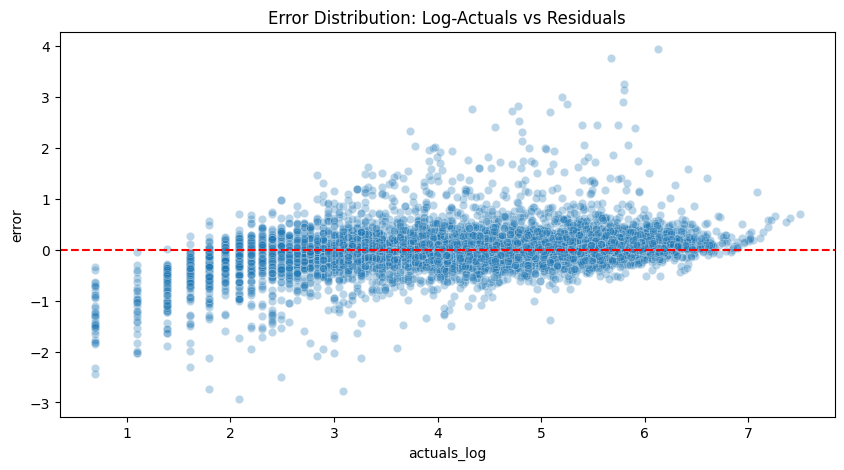

Discovery: Calculating transaction velocity and salary-cycle affinity...


UniqueID,salary_cycle_ratio
str,f64
"""8fe16f45-39a1-40c4-873b-ac00c4…",0.402981
"""a7e5268d-14cb-4dec-871b-832304…",0.432619
"""5bfda505-2c56-4d63-8631-b3ad07…",0.444007
"""dd20f1cd-01c2-4c54-b67a-029e6a…",0.485484
"""e573ff68-6d00-4c58-811f-72d634…",0.633803


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Error Analysis: Where is the model missing?
train_eval = train_data.copy()
train_eval['preds_log'] = oof_preds
train_eval['actuals_log'] = np.log1p(train_eval['next_3m_txn_count'])
train_eval['error'] = train_eval['actuals_log'] - train_eval['preds_log']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=train_eval, x='actuals_log', y='error', alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Error Distribution: Log-Actuals vs Residuals')
plt.show()

# 2. Advanced Feature Engineering Concept
def engineer_enhanced_features(df_trans, df_fin):
    # Salary cycle check (Days 25-31 and 1-5)
    print("Discovery: Calculating transaction velocity and salary-cycle affinity...")

    salary_affinity = df_trans.with_columns([
        pl.col('TransactionDate').dt.day().alias('dom')
    ]).with_columns([
        pl.when(pl.col('dom').is_in(list(range(25,32)) + list(range(1,6))))
        .then(1).otherwise(0).alias('is_salary_period')
    ]).group_by('UniqueID').agg(
        pl.col('is_salary_period').mean().alias('salary_cycle_ratio')
    )

    return salary_affinity

enhanced_meta = engineer_enhanced_features(trans_clean, pl.read_parquet(os.path.join(BASE_DIR, 'financials_features.parquet')))
display(enhanced_meta.head())

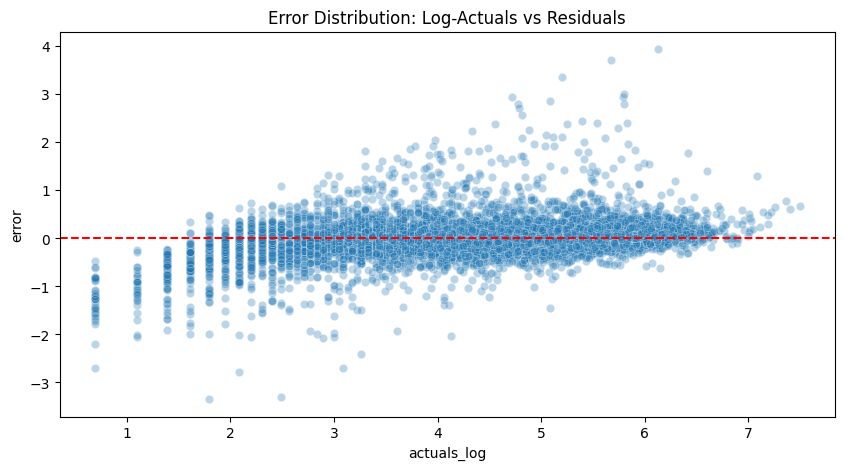

Discovery: Calculating transaction velocity and salary-cycle affinity...


UniqueID,salary_cycle_ratio
str,f64
"""a7a2d794-9342-4d9f-a838-523280…",0.539501
"""fc7baf52-23b7-46fe-beb6-eed66e…",0.423208
"""9a6c0ec4-0bb8-487d-adf0-76b9ac…",0.431201
"""b78f7b61-2fdc-4bc0-a2cc-174900…",0.406874
"""aeb29b06-27c2-41dd-845e-c4f048…",0.437342


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Error Analysis: Where is the model missing?
train_eval = train_data.copy()
train_eval['preds_log'] = oof_preds
train_eval['actuals_log'] = np.log1p(train_eval['next_3m_txn_count'])
train_eval['error'] = train_eval['actuals_log'] - train_eval['preds_log']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=train_eval, x='actuals_log', y='error', alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.title('Error Distribution: Log-Actuals vs Residuals')
plt.show()

# 2. Advanced Feature Engineering Concept
def engineer_enhanced_features(df_trans, df_fin):
    # Velocity: Is the user getting more active recently compared to their own history?
    # Day-of-Month: Percentage of transactions happening between the 25th and 5th (Salary cycle)
    # Financial Ratios: Interest Income per Transaction
    print("Discovery: Calculating transaction velocity and salary-cycle affinity...")

    # Salary cycle check (Days 25-31 and 1-5)
    df_trans = df_trans.with_columns([
        pl.col('TransactionDate').dt.day().alias('dom')
    ]).with_columns([
        pl.when(pl.col('dom').is_in(list(range(25,32)) + list(range(1,6))))
        .then(1).otherwise(0).alias('is_salary_period')
    ])

    salary_affinity = df_trans.group_by('UniqueID').agg(
        pl.col('is_salary_period').mean().alias('salary_cycle_ratio')
    )

    return salary_affinity

enhanced_meta = engineer_enhanced_features(trans_clean, pl.read_parquet(os.path.join(BASE_DIR, 'financials_features.parquet')))
display(enhanced_meta.head())